# Step 8: Governance Risk Score

Combines the six dimensions into a risk profile and one score (survey section 5.6):

GRS = sum of w_i x r_i, with each risk r_i in [0, 1] and weights summing to 1.

Rules followed:
- Only dimensions that were actually assessed take part; the others are listed, not guessed.
- The profile and the list of failing dimensions are always shown beside the score, because an average can hide one bad dimension.
- The weights are an assumption. Equal weights are the default and a sensitivity table shows other schemes.

**Data quality is audited on the raw extract**, not the cleaned split. Cleaned data would always look perfect.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.model import load_processed, build_dtypes, apply_dtypes

PROCESSED_DIR = os.path.abspath("../data/processed")
RESULTS_DIR = os.path.abspath("../results")
from src.data_pipeline import load_acs_income, build_income_task
from src.audit.data_quality import audit_data_quality_result
from src.audit.run_all import run_all_audits
from src.audit.grs import compute_grs, grs_sensitivity
from src.audit.common import save_result
X_train, X_test, y_train, y_test, g_train, g_test = load_processed(PROCESSED_DIR)
dtypes = build_dtypes(X_train, X_test)
Xte = apply_dtypes(X_test, dtypes)
yte = y_test.to_numpy()

model = XGBClassifier()
model.load_model(os.path.join(RESULTS_DIR, "baseline_xgb.json"))
p = model.predict_proba(Xte)[:, 1]
print("Test rows:", Xte.shape)


Test rows: (38642, 10)


## 1. Data quality on the raw extract

Uses the Census data cached by notebook 01 (the raw rows after the ACSIncome filters, before de-duplication).

In [2]:
acs = load_acs_income(state="CA", year="2022")
raw_features, _, _ = build_income_task(acs, year="2022")
dq = audit_data_quality_result(raw_features)
print(dq.summary())
save_result(dq, os.path.join(RESULTS_DIR, "data_quality_result.json"))

Data quality: risk 0.367 (pass)
  - 200,577 rows audited: missing value rate 0.00%, duplicate rate 3.67%, completeness 100.00%.


## 2. Run every audit and aggregate

In [3]:
results, grs, _ = run_all_audits(model, Xte, y_true=yte, precomputed={"data_quality": dq})
for r in results.values():
    print(r.summary(), "\n")

Data quality: risk 0.367 (pass)
  - 200,577 rows audited: missing value rate 0.00%, duplicate rate 3.67%, completeness 100.00%. 

Explainability: risk 0.791 (fail)
  - Most influential features: OCCP (26.7%), WKHP (18.8%), AGEP (13.9%).
  - Sensitive features ['RAC1P', 'SEX', 'POBP'] carry 12.5% of total SHAP importance (limit 10%). Read with the fairness module: this shows influence, not proof of discrimination.
  - 7.9% of decisions change when only SEX is changed (limit 5%).
  - 7.6% of decisions change when only RAC1P is changed (limit 5%). 

Robustness: risk 0.376 (pass)
  - noise (0.2): accuracy falls 1.1% relative; 5.3% of decisions change.
  - missing (0.1): accuracy falls 3.8% relative; 8.5% of decisions change.
  - swap (0.05): accuracy falls 1.2% relative; 2.9% of decisions change. 

Fairness: risk 1.000 (fail)
  - RAC1P: demographic parity difference 0.388 exceeds 0.10 (group 1.0 selected 61.5%, group 8.0 selected 22.7%).
  - RAC1P: disparate impact ratio 0.369 is below the

In [4]:
print(f"GRS = {grs.score:.3f}  ({grs.band})   worst dimension: {grs.worst_dimension}")
print("Failing dimensions:", grs.failing or "none")
print("Not assessed:", grs.not_assessed or "none")
grs.profile[["dimension", "risk", "status", "weight", "contribution"]].round(3)

GRS = 0.557  (High)   worst dimension: Fairness
Failing dimensions: ['Fairness', 'Explainability']
Not assessed: none


,dimension,risk,status,weight,contribution
key,,,,,
data_quality,Data quality,0.367,pass,0.167,0.061
fairness,Fairness,1.000,fail,0.167,0.167
explainability,Explainability,0.791,fail,0.167,0.132
reliability,Reliability,0.326,pass,0.167,0.054
robustness,Robustness,0.376,pass,0.167,0.063
oversight,Human oversight,0.482,pass,0.167,0.080


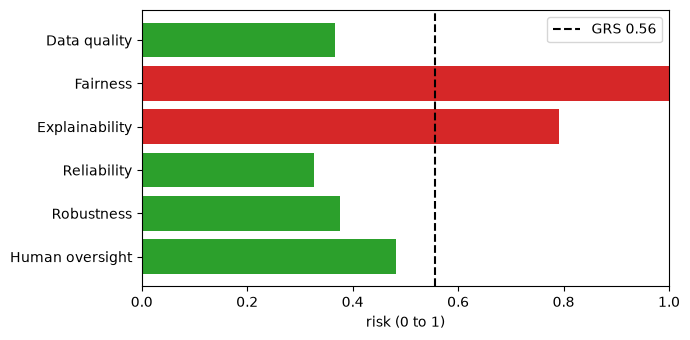

In [5]:
p_ = grs.profile
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(p_["dimension"][::-1], p_["risk"][::-1], color=["tab:red" if s == "fail" else "tab:orange" if s == "warn" else "tab:green" for s in p_["status"][::-1]])
ax.axvline(grs.score, color="k", ls="--", label=f"GRS {grs.score:.2f}")
ax.set_xlim(0, 1); ax.set_xlabel("risk (0 to 1)"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Does the score depend on the weights?

In [6]:
grs_sensitivity(results).round(3)

,grs,band
weight_scheme,,
equal,0.557,High
fairness_heavy,0.628,High
technical_heavy,0.489,Moderate
governance_heavy,0.636,High


In [7]:
out = {"grs": grs.score, "band": grs.band, "worst_dimension": grs.worst_dimension,
       "failing": grs.failing, "not_assessed": grs.not_assessed,
       "profile": grs.profile.reset_index().to_dict(orient="records")}
with open(os.path.join(RESULTS_DIR, "grs_result.json"), "w") as f:
    json.dump(out, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Saved")

Saved


## Summary and next step

- Aggregated six dimensions into a risk profile and a Governance Risk Score, with failing dimensions and unassessed dimensions stated.
- Showed how the score moves under four weighting schemes.

**Next:** run the dashboard (`streamlit run app/dashboard.py`), then Phase 2 (synthetic welfare dataset with injected defects).